# 09 — Разведочный анализ датасета (Глава 2 ВКР)

Описание датасета для раздела 2.3.2 «Алгоритм подготовки данных». Все графики сохраняются в `reports/figures/dataset/` с DPI=300; подписи на русском, шрифт **DejaVu Sans**.

### Что считаем
1. Сводная таблица: размер каждого split, доли v3.1/v4.0, доли d_ru, EPSS/KEV/exploit.
2. Распределение по источникам (NVD vs БДУ ФСТЭК) — pie chart.
3. Дисбаланс классов по 12 метрикам CVSS v4.0 — 3×4 grid bar plots.
4. Длины описаний в токенах (en/ru — overlay).
5. Распределение итоговых CVSS-баллов и severity (Critical/.../None).
6. Топ-20 наиболее частых CWE в train set.
7. Корреляции между метриками v4.0 (Cramer's V heatmap).


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = ROOT / 'reports' / 'figures' / 'dataset'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Figures →', FIG_DIR)

Figures → C:\Users\Артём\Desktop\diplom\reports\figures\dataset


## 1. Загрузка train/val/test и сводная статистика

In [2]:
splits = {}
for name in ['train', 'val', 'test']:
    splits[name] = pd.read_parquet(ROOT / 'data' / 'processed' / f'{name}.parquet')
    print(f'{name}: {len(splits[name]):,} строк')

train: 122,913 строк
val: 26,385 строк
test: 26,348 строк


In [3]:
def split_stats(df: pd.DataFrame) -> dict:
    n = len(df)
    v3 = df['cvss_v3_vector'].notna().sum()
    v4 = df['cvss_v4_vector'].notna().sum()
    ru = df['d_ru'].notna().sum()
    en = df['d_en'].notna().sum()
    epss = df['epss'].notna().sum()
    kev = (df['kev'].fillna(0) > 0).sum()
    expl = (df['exploit'].fillna(0) > 0).sum()
    return {
        'Размер': n,
        'CVSS v3.1': f'{v3:,} ({v3/n:.1%})',
        'CVSS v4.0': f'{v4:,} ({v4/n:.1%})',
        'Описания d_ru': f'{ru:,} ({ru/n:.1%})',
        'Описания d_en': f'{en:,} ({en/n:.1%})',
        'EPSS': f'{epss:,} ({epss/n:.1%})',
        'CISA KEV': f'{kev:,} ({kev/n:.1%})',
        'ExploitDB': f'{expl:,} ({expl/n:.1%})',
    }

summary = pd.DataFrame({k: split_stats(v) for k, v in splits.items()})
summary.index.name = 'Показатель'
summary

,train,val,test
Показатель,,,
Размер,122913,26385,26348
CVSS v3.1,"122,750 (99.9%)","26,341 (99.8%)","26,317 (99.9%)"
CVSS v4.0,"4,715 (3.8%)","1,041 (3.9%)",972 (3.7%)
Описания d_ru,"46,918 (38.2%)","10,038 (38.0%)","10,150 (38.5%)"
Описания d_en,"109,560 (89.1%)","23,545 (89.2%)","23,479 (89.1%)"
EPSS,"122,585 (99.7%)","26,325 (99.8%)","26,294 (99.8%)"
CISA KEV,953 (0.8%),200 (0.8%),201 (0.8%)
ExploitDB,"2,404 (2.0%)",552 (2.1%),505 (1.9%)


In [4]:
# Сохраняем сводную таблицу в Markdown для копирования в главу 2 ВКР
md_path = ROOT / 'reports' / 'dataset_summary.md'
md_path.write_text(
    '# Сводная статистика датасета\n\n' + summary.to_markdown() + '\n',
    encoding='utf-8',
)
print('Сохранено в', md_path)
print()
print(summary.to_markdown())

Сохранено в C:\Users\Артём\Desktop\diplom\reports\dataset_summary.md

| Показатель    | train           | val            | test           |
|:--------------|:----------------|:---------------|:---------------|
| Размер        | 122913          | 26385          | 26348          |
| CVSS v3.1     | 122,750 (99.9%) | 26,341 (99.8%) | 26,317 (99.9%) |
| CVSS v4.0     | 4,715 (3.8%)    | 1,041 (3.9%)   | 972 (3.7%)     |
| Описания d_ru | 46,918 (38.2%)  | 10,038 (38.0%) | 10,150 (38.5%) |
| Описания d_en | 109,560 (89.1%) | 23,545 (89.2%) | 23,479 (89.1%) |
| EPSS          | 122,585 (99.7%) | 26,325 (99.8%) | 26,294 (99.8%) |
| CISA KEV      | 953 (0.8%)      | 200 (0.8%)     | 201 (0.8%)     |
| ExploitDB     | 2,404 (2.0%)    | 552 (2.1%)     | 505 (1.9%)     |


## 2. Распределение по источникам (NVD vs БДУ ФСТЭК)

Записи из БДУ ФСТЭК идентифицируются по префиксу `BDU:`, записи из NVD — по префиксу `CVE-` в колонке `id`. (Поле `cve_id` содержит CVE-идентификатор даже у БДУ-записей.)

NVD          75995
БДУ ФСТЭК    46918
Name: count, dtype: int64


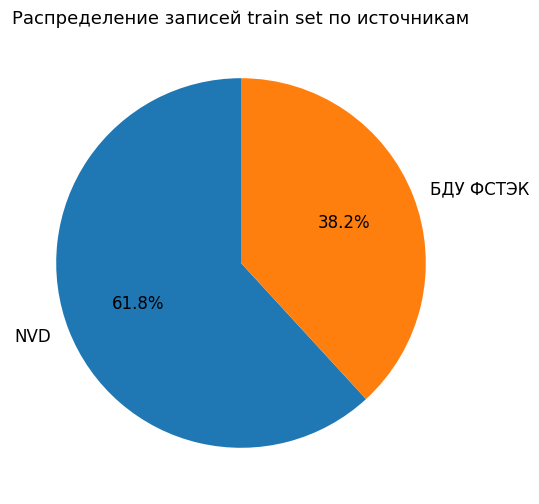

In [5]:
train = splits['train']
source = np.where(train['id'].astype(str).str.startswith('BDU'),
                  'БДУ ФСТЭК', 'NVD')
src_counts = pd.Series(source).value_counts()
print(src_counts)

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#1f77b4', '#ff7f0e']
ax.pie(src_counts.values, labels=src_counts.index, colors=colors,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax.set_title('Распределение записей train set по источникам', fontsize=13)
fig.savefig(FIG_DIR / 'sources_pie.png')
plt.show()

## 3. Распределение классов по 12 метрикам CVSS v4.0

Берём только записи с непустым `cvss_v4_vector` (4 715 / 1 041 / 972 для train/val/test). Покажет дисбаланс по каждой из 12 метрик.

In [6]:
from src.data_preparation.cvss_vector_parser import (
    V4_METRIC_ORDER, V4_LABEL_MAPS, parse_v4_vector,
)

def parse_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for vec in df['cvss_v4_vector'].dropna():
        try:
            rows.append(parse_v4_vector(vec))
        except Exception:
            continue
    return pd.DataFrame(rows)

train_v4 = parse_metrics_df(splits['train'])
test_v4 = parse_metrics_df(splits['test'])
print(f'train v4: {len(train_v4)}, test v4: {len(test_v4)}')
train_v4.head()

C:\Users\Артём\Desktop\diplom\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train v4: 4715, test v4: 972


,AV,AC,AT,PR,UI,VC,VI,VA,SC,SI,SA,E
0,N,L,N,L,N,L,L,L,N,N,N,A
1,N,L,N,N,N,L,N,N,N,N,N,A
2,N,L,N,N,N,L,L,L,N,N,N,A
3,N,L,N,L,N,L,L,L,N,N,N,A
4,N,L,N,L,N,L,N,N,N,N,N,NaN


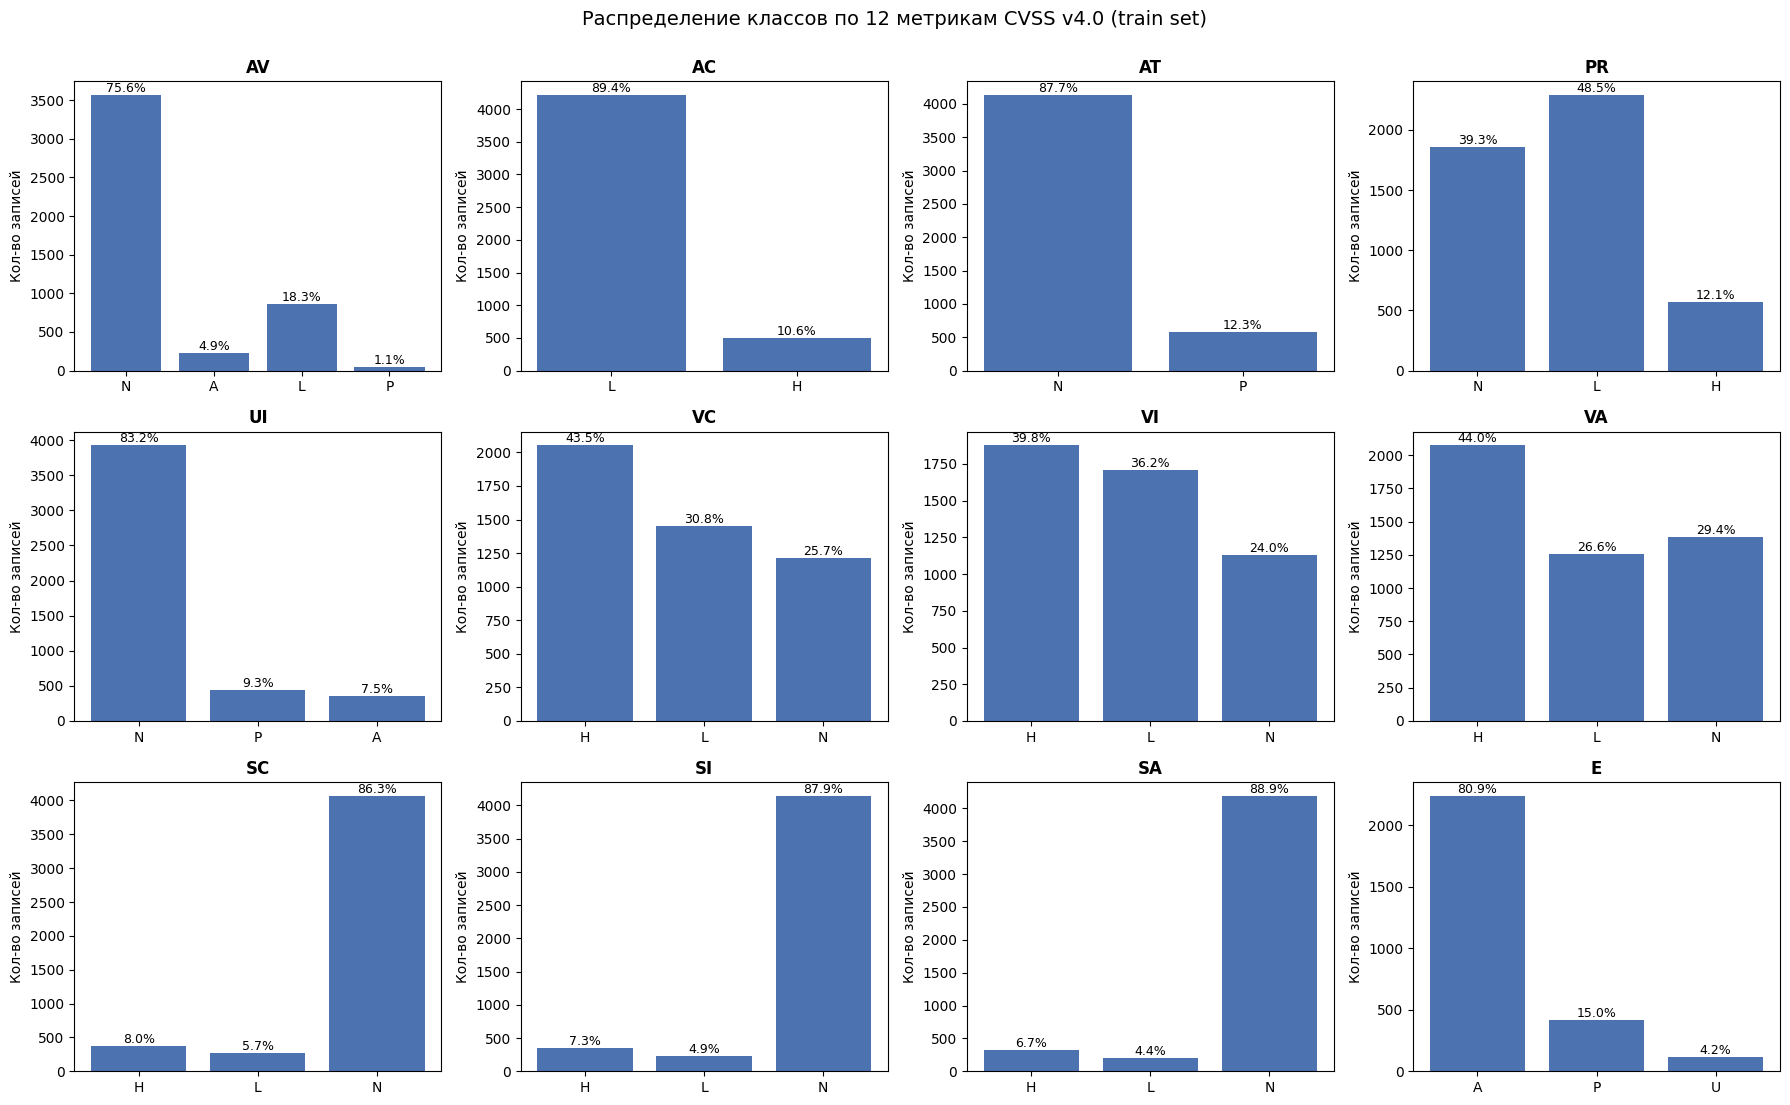

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, metric in zip(axes.flat, V4_METRIC_ORDER):
    labels = V4_LABEL_MAPS[metric]
    counts = train_v4[metric].value_counts().reindex(labels, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color='#4c72b0')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Кол-во записей')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val,
                f'{val/counts.sum():.1%}',
                ha='center', va='bottom', fontsize=9)
fig.suptitle('Распределение классов по 12 метрикам CVSS v4.0 (train set)',
             fontsize=14, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metrics_class_distribution.png')
plt.show()

In [8]:
# Численная таблица дисбаланса: доля мажоритарного класса по каждой метрике
imb = []
for metric in V4_METRIC_ORDER:
    counts = train_v4[metric].value_counts(normalize=True)
    imb.append({
        'Метрика': metric,
        'Кол-во классов': len(V4_LABEL_MAPS[metric]),
        'Доля мажоритарного класса': f'{counts.iloc[0]:.1%}',
        'Мажоритарный класс': counts.index[0],
    })
imb_df = pd.DataFrame(imb)
(ROOT / 'reports' / 'class_imbalance.md').write_text(
    '# Дисбаланс классов\n\n' + imb_df.to_markdown(index=False) + '\n',
    encoding='utf-8',
)
imb_df

,Метрика,Кол-во классов,Доля мажоритарного класса,Мажоритарный класс
0,AV,4,75.6%,N
1,AC,2,89.4%,L
2,AT,2,87.7%,N
3,PR,3,48.5%,L
4,UI,3,83.2%,N
5,VC,3,43.5%,H
6,VI,3,39.8%,H
7,VA,3,44.0%,H
8,SC,3,86.3%,N
9,SI,3,87.9%,N


## 4. Длины описаний в токенах (en / ru)

In [9]:
from src.data_preparation.tokenizer_wrapper import CVSSTokenizer
import warnings
warnings.filterwarnings('ignore')

tok = CVSSTokenizer()

def token_lens(series: pd.Series, sample_size: int = 5000) -> np.ndarray:
    texts = series.dropna().sample(
        min(sample_size, series.dropna().shape[0]), random_state=42
    ).tolist()
    lens = []
    for batch_start in range(0, len(texts), 64):
        batch = texts[batch_start:batch_start + 64]
        out = tok.tokenize_batch(batch, max_length=512)
        lens.extend([sum(m) for m in out['attention_mask']])
    return np.array(lens)

lens_en = token_lens(splits['train']['d_en'])
lens_ru = token_lens(splits['train']['d_ru'])
print(f'en: mean={lens_en.mean():.1f}, median={np.median(lens_en):.0f}, p95={np.percentile(lens_en, 95):.0f}')
print(f'ru: mean={lens_ru.mean():.1f}, median={np.median(lens_ru):.0f}, p95={np.percentile(lens_ru, 95):.0f}')

en: mean=93.1, median=71, p95=229
ru: mean=86.8, median=84, p95=122


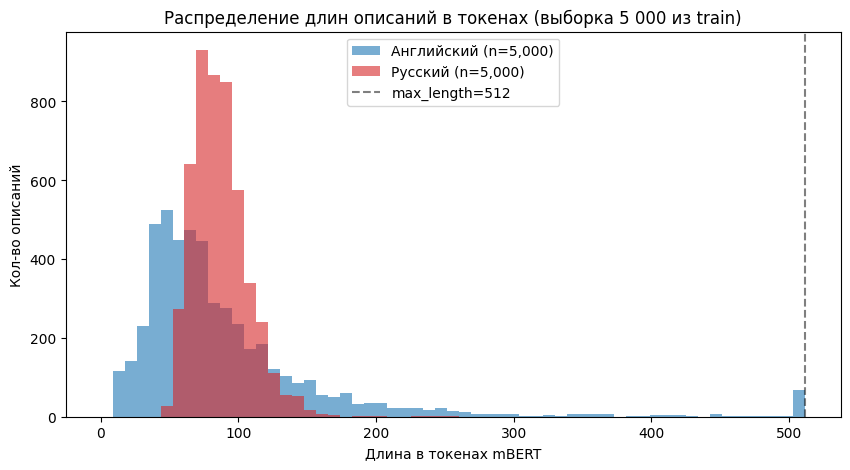

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 512, 60)
ax.hist(lens_en, bins=bins, alpha=0.6, label=f'Английский (n={len(lens_en):,})',
        color='#1f77b4')
ax.hist(lens_ru, bins=bins, alpha=0.6, label=f'Русский (n={len(lens_ru):,})',
        color='#d62728')
ax.axvline(512, color='black', linestyle='--', alpha=0.5, label='max_length=512')
ax.set_xlabel('Длина в токенах mBERT')
ax.set_ylabel('Кол-во описаний')
ax.set_title('Распределение длин описаний в токенах (выборка 5 000 из train)')
ax.legend()
fig.savefig(FIG_DIR / 'token_lengths.png')
plt.show()

## 5. Итоговые CVSS-баллы и severity

In [11]:
from src.cvss_calculator import CVSSCalculator
calc = CVSSCalculator()

scores = []
severities = []
for _, row in train_v4.iterrows():
    metrics = {m: (row[m] if isinstance(row[m], str) else ('A' if m == 'E' else 'N'))
               for m in V4_METRIC_ORDER}
    score, sev, _ = calc.calculate(metrics)
    scores.append(score)
    severities.append(sev)
scores = np.array(scores)
print(f'mean score = {scores.mean():.2f}, median = {np.median(scores):.2f}')

mean score = 6.73, median = 6.90


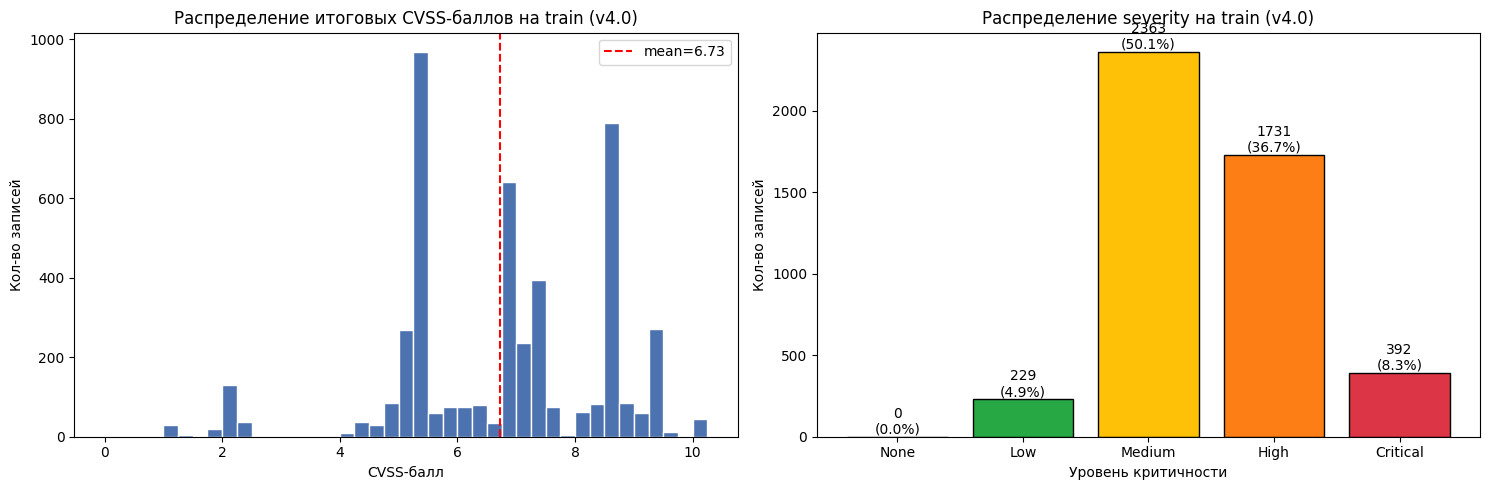

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(scores, bins=np.arange(0, 10.5, 0.25), color='#4c72b0', edgecolor='white')
axes[0].set_xlabel('CVSS-балл')
axes[0].set_ylabel('Кол-во записей')
axes[0].set_title('Распределение итоговых CVSS-баллов на train (v4.0)')
axes[0].axvline(scores.mean(), color='red', linestyle='--', label=f'mean={scores.mean():.2f}')
axes[0].legend()

sev_order = ['None', 'Low', 'Medium', 'High', 'Critical']
sev_colors = ['#6c757d', '#28a745', '#ffc107', '#fd7e14', '#dc3545']
sev_counts = pd.Series(severities).value_counts().reindex(sev_order, fill_value=0)
bars = axes[1].bar(sev_counts.index, sev_counts.values, color=sev_colors,
                   edgecolor='black')
for bar, val in zip(bars, sev_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val,
                 f'{val}\n({val/sev_counts.sum():.1%})',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_xlabel('Уровень критичности')
axes[1].set_ylabel('Кол-во записей')
axes[1].set_title('Распределение severity на train (v4.0)')

fig.tight_layout()
fig.savefig(FIG_DIR / 'score_severity_distribution.png')
plt.show()

## 6. Топ-20 наиболее частых CWE в train set

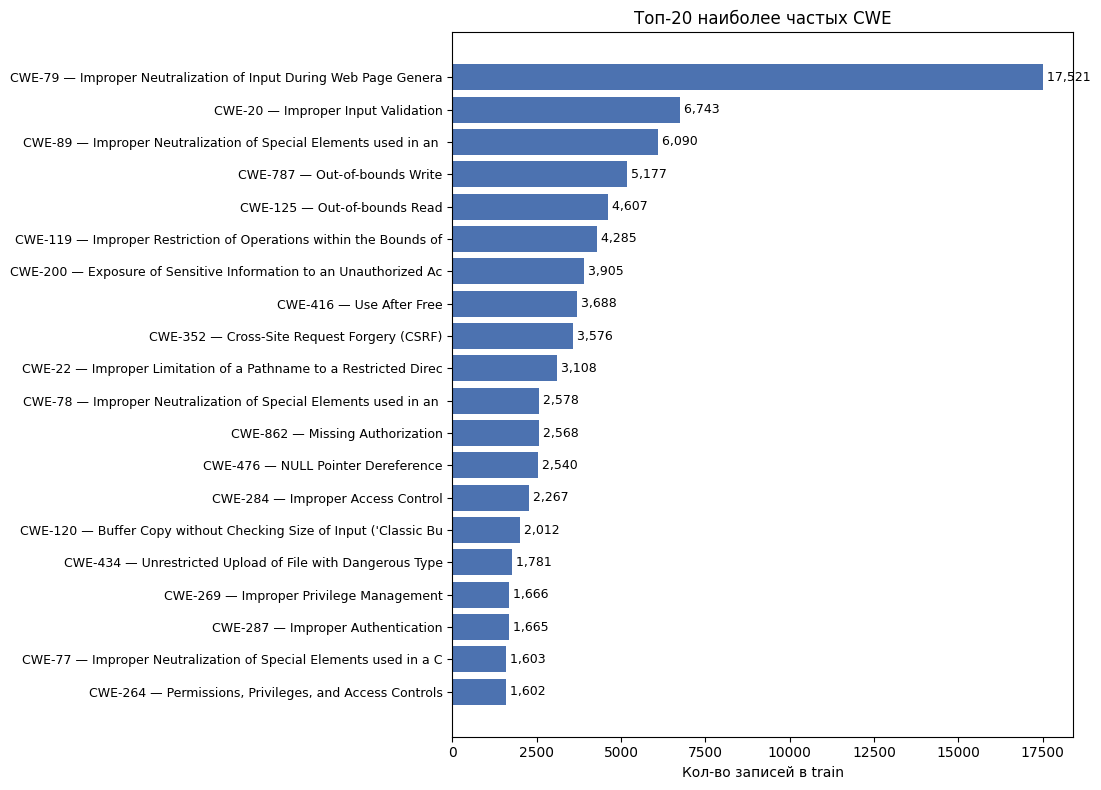

In [13]:
cwe_counts = splits['train']['cwe_id'].value_counts().head(20)
cwe_names = (splits['train'][['cwe_id', 'cwe_name']]
             .drop_duplicates('cwe_id')
             .set_index('cwe_id')['cwe_name'])

fig, ax = plt.subplots(figsize=(11, 8))
labels = []
for cwe in cwe_counts.index:
    nm = str(cwe_names.get(cwe, ''))[:55]
    labels.append(f'{cwe} — {nm}')
y = np.arange(len(cwe_counts))[::-1]
bars = ax.barh(y, cwe_counts.values, color='#4c72b0')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Кол-во записей в train')
ax.set_title('Топ-20 наиболее частых CWE')
for bar, val in zip(bars, cwe_counts.values):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:,}',
            va='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'top20_cwe.png')
plt.show()

## 7. Корреляции между 11 базовыми метриками v4.0

Используем Cramer's V — мера ассоциации для категориальных величин (0 → независимы, 1 → полная зависимость). E (Exploit Maturity) исключаем — это эксплойт-метрика, а не базовая.

In [14]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y).values
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.sum()
    r, k = table.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1)))) if min(r, k) > 1 else 0.0

base = [m for m in V4_METRIC_ORDER if m != 'E']
mat = pd.DataFrame(0.0, index=base, columns=base)
for a in base:
    for b in base:
        if a == b:
            mat.loc[a, b] = 1.0
        else:
            mat.loc[a, b] = cramers_v(train_v4[a], train_v4[b])
mat.round(2)

,AV,AC,AT,PR,UI,VC,VI,VA,SC,SI,SA
AV,1.00,0.30,0.22,0.15,0.19,0.16,0.22,0.18,0.09,0.09,0.13
AC,0.30,1.00,0.30,0.12,0.27,0.14,0.16,0.12,0.09,0.09,0.09
AT,0.22,0.30,1.00,0.11,0.25,0.12,0.17,0.13,0.22,0.22,0.20
PR,0.15,0.12,0.11,1.00,0.10,0.07,0.13,0.09,0.11,0.11,0.13
UI,0.19,0.27,0.25,0.10,1.00,0.10,0.10,0.14,0.15,0.13,0.05
VC,0.16,0.14,0.12,0.07,0.10,1.00,0.62,0.56,0.14,0.12,0.15
VI,0.22,0.16,0.17,0.13,0.10,0.62,1.00,0.59,0.14,0.16,0.16
VA,0.18,0.12,0.13,0.09,0.14,0.56,0.59,1.00,0.15,0.13,0.15
SC,0.09,0.09,0.22,0.11,0.15,0.14,0.14,0.15,1.00,0.76,0.56
SI,0.09,0.09,0.22,0.11,0.13,0.12,0.16,0.13,0.76,1.00,0.63


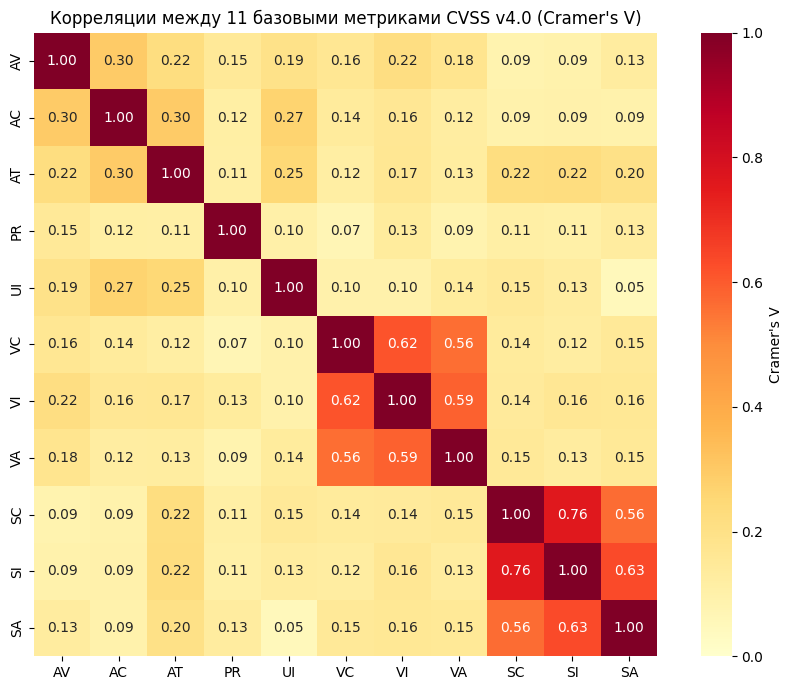

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, square=True, cbar_kws={'label': "Cramer's V"})
ax.set_title('Корреляции между 11 базовыми метриками CVSS v4.0 (Cramer\'s V)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'metric_correlations.png')
plt.show()

## Итог: Markdown-сводка для главы 2 ВКР

Сохранили `reports/dataset_summary.md` и `reports/class_imbalance.md`. Графики — в `reports/figures/dataset/`.

In [16]:
print('Создано:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(' •', f.relative_to(ROOT))
print(' •', (ROOT / 'reports' / 'dataset_summary.md').relative_to(ROOT))
print(' •', (ROOT / 'reports' / 'class_imbalance.md').relative_to(ROOT))

Создано:
 • reports\figures\dataset\metric_correlations.png
 • reports\figures\dataset\metrics_class_distribution.png
 • reports\figures\dataset\score_severity_distribution.png
 • reports\figures\dataset\sources_pie.png
 • reports\figures\dataset\token_lengths.png
 • reports\figures\dataset\top20_cwe.png
 • reports\dataset_summary.md
 • reports\class_imbalance.md
